# Trip Extraction — Handover-Based

Builds on `build_stage_onefile.ipynb`. Assumes `handover_events` already exists in DuckDB.

## Concept
- Each vehicle polls every **450 seconds** (~7.5 min), reporting its current `cell_id`.
- A **cell handover** (cell_id changes between consecutive polls) means the vehicle is **moving**.
- A vehicle is **stationary/parked** when it stays on the same cell for `STATIONARY_POLLS` consecutive polls.
- A **trip** is a continuous run of cell handovers, bounded by stationary periods on either side.

```
  polls:  [C1] [C2] [C3] [C3] [C3] [C3] [C4] [C5] [C5] [C5]
          move move move same same same move move same same
          |------- TRIP 1 -------|  parked  |--- TRIP 2 ---|
```

In [1]:
## Config — tune these to your data

import duckdb
import pandas as pd
from pathlib import Path
from datetime import datetime
import shutil

DB_PATH   = "/home/jovyan/data/analytics.duckdb"
STAGE_DIR = Path("/home/jovyan/data/stage/trips")

POLL_SECONDS = 450          # vehicle reports every 450s (~7.5 min)

# A vehicle is considered STATIONARY when it stays on the same cell
# for this many consecutive polls without a handover.
# 2 polls = 15 min of no movement before trip is considered ended.
STATIONARY_POLLS = 2

# Minimum number of cell handovers for a trip to be recorded.
# 2 = ignore single-hop moves (brief lane-change / cell boundary flicker).
MIN_HANDOVERS = 2

# ditch switching back and forth between two cells on a boundary...
MIN_CELLS = 3

# Optionally filter to a specific date (None = all dates in the table)
EVENT_DATE_FILTER = None   # e.g. '2025-06-15'

STAGE_DIR.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(DB_PATH)
print(f"Config: STATIONARY_POLLS={STATIONARY_POLLS}, MIN_HANDOVERS={MIN_HANDOVERS}")
print(f"Connected to {DB_PATH}")

if STAGE_DIR.exists():
    shutil.rmtree(STAGE_DIR)

Config: STATIONARY_POLLS=2, MIN_HANDOVERS=2
Connected to /home/jovyan/data/analytics.duckdb


In [ ]:
## Rebuild handover_events from parquet if needed

import duckdb

con = duckdb.connect(DB_PATH)

con.execute("DROP TABLE IF EXISTS handover_events")

con.execute("""
CREATE TABLE handover_events AS
SELECT *
FROM read_parquet('/home/jovyan/data/stage/handover_events/**/*.parquet')
""")

print(con.execute("""
    SELECT COUNT(*) AS rows, 
           MIN(event_ts) AS min_event, 
           MAX(event_ts) AS max_event,
           COUNT(DISTINCT vehicle_id) AS vehicles
    FROM handover_events
""").df())

In [2]:
## Step 1: Load handover_events, one row per poll, sorted per vehicle

date_clause = f"WHERE event_date = '{EVENT_DATE_FILTER}'" if EVENT_DATE_FILTER else ""

df = con.execute(f"""
    SELECT
        vehicle_id,
        imsi,
        event_ts,
        cell_id,
        rat,
        event_date
    FROM handover_events
    {date_clause}
    ORDER BY vehicle_id, event_ts
""").df()

print(f"Loaded {len(df):,} polls | {df['vehicle_id'].nunique():,} vehicles | "
      f"{df['event_date'].nunique()} date(s)")
df.head(3)

Loaded 179 polls | 1 vehicles | 1 date(s)


,vehicle_id,imsi,event_ts,cell_id,rat,event_date
0,F140A413CDBACB245F79DAE1D7438EC4,000000000000000,2025-01-01 00:02:01.793,69492489,4G,2025-01-01
1,F140A413CDBACB245F79DAE1D7438EC4,000000000000000,2025-01-01 00:10:05.626,69492489,4G,2025-01-01
2,F140A413CDBACB245F79DAE1D7438EC4,000000000000000,2025-01-01 00:18:09.436,69492708,4G,2025-01-01


In [3]:
## Step 2: Detect cell handovers and stationary periods
#
# For each vehicle, compare each poll's cell_id to the previous poll.
# Then count how many consecutive polls the vehicle has been on the same cell.

df = df.sort_values(['vehicle_id', 'event_ts']).reset_index(drop=True)

# Did the cell_id change from the previous poll for this vehicle?
df['prev_cell'] = df.groupby('vehicle_id')['cell_id'].shift(1)
df['cell_changed'] = df['cell_id'] != df['prev_cell']  # True = handover / first poll

# Group consecutive same-cell polls per vehicle into runs.
# Each handover resets the run counter.
df['cell_run_id'] = df.groupby('vehicle_id')['cell_changed'].cumsum()

# Within each run, count position: 1 = first poll on this cell, 2 = second, ...
df['same_cell_poll_count'] = df.groupby(['vehicle_id', 'cell_run_id']).cumcount() + 1

# Stationary = vehicle has been on the same cell for >= STATIONARY_POLLS polls
df['stationary'] = df['same_cell_poll_count'] >= STATIONARY_POLLS

# How many handovers happened today?
n_handovers = df['cell_changed'].sum() - df['vehicle_id'].nunique()  # subtract first-poll flags
print(f"Total cell handovers detected: {n_handovers:,}")
print(f"Stationary polls (same cell >= {STATIONARY_POLLS} consecutive): {df['stationary'].sum():,}")
df[['vehicle_id','event_ts','cell_id','cell_changed','same_cell_poll_count','stationary']].head(10)

Total cell handovers detected: 546,936
Stationary polls (same cell >= 2 consecutive): 2,553,006


,vehicle_id,event_ts,cell_id,cell_changed,same_cell_poll_count,stationary
0,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:03:12.538,182286856,True,1,False
1,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:11:16.398,182286856,False,2,True
2,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:19:20.230,182286856,False,3,True
3,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:27:24.005,182286870,True,1,False
4,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:35:27.895,182286856,True,1,False
5,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:43:31.673,182286870,True,1,False
6,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:51:35.500,182286870,False,2,True
7,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:59:39.359,182286870,False,3,True
8,00064787112BFA3E3B89C7828C48FB97,2025-06-15 01:07:43.256,182286856,True,1,False
9,00064787112BFA3E3B89C7828C48FB97,2025-06-15 01:15:47.088,182286856,False,2,True


In [4]:
## Step 3: Assign trip IDs
#
# A new trip starts when a handover occurs AND the vehicle was previously stationary
# (or it's the vehicle's very first poll).
#
# Polls that are stationary (parked) are NOT part of any trip.

# Was the previous poll stationary? (NaN for first poll -> treat as True so first handover starts a trip)
df['prev_stationary'] = df.groupby('vehicle_id')['stationary'].shift(1).fillna(True)

# Trip-start: a handover that comes out of a stationary period
df['trip_start_flag'] = df['cell_changed'] & df['prev_stationary']

# Sequential trip number per vehicle (increments at each trip start)
df['trip_seq'] = df.groupby('vehicle_id')['trip_start_flag'].cumsum()

# A poll is part of a trip if it is NOT stationary
df['in_trip'] = ~df['stationary']

# Only assign a trip_id to in-trip polls
df['trip_id'] = None
mask = df['in_trip']
df.loc[mask, 'trip_id'] = (
    df.loc[mask, 'vehicle_id'] + '_trip_' +
    df.loc[mask, 'trip_seq'].astype(str).str.zfill(3)
)

n_trips_raw = df.loc[mask, 'trip_id'].nunique()
print(f"Raw trips identified: {n_trips_raw:,}")
print(f"Polls in active trips: {mask.sum():,} / {len(df):,} total")
df[['vehicle_id','event_ts','cell_id','cell_changed','stationary','in_trip','trip_id']].head(12)

Raw trips identified: 246,997
Polls in active trips: 565,529 / 3,118,535 total


,vehicle_id,event_ts,cell_id,cell_changed,stationary,in_trip,trip_id
0,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:03:12.538,182286856,True,False,True,00064787112BFA3E3B89C7828C48FB97_trip_001
1,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:11:16.398,182286856,False,True,False,None
2,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:19:20.230,182286856,False,True,False,None
3,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:27:24.005,182286870,True,False,True,00064787112BFA3E3B89C7828C48FB97_trip_002
4,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:35:27.895,182286856,True,False,True,00064787112BFA3E3B89C7828C48FB97_trip_002
5,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:43:31.673,182286870,True,False,True,00064787112BFA3E3B89C7828C48FB97_trip_002
6,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:51:35.500,182286870,False,True,False,None
7,00064787112BFA3E3B89C7828C48FB97,2025-06-15 00:59:39.359,182286870,False,True,False,None
8,00064787112BFA3E3B89C7828C48FB97,2025-06-15 01:07:43.256,182286856,True,False,True,00064787112BFA3E3B89C7828C48FB97_trip_003
9,00064787112BFA3E3B89C7828C48FB97,2025-06-15 01:15:47.088,182286856,False,True,False,None


In [5]:
## Step 4: Build the handover sequence per trip
#
# Keep only polls that are IN a trip AND represent an actual cell change.
# This gives us the ordered sequence of cells the vehicle passed through.

# Handover events within trips
df_moves = df[df['in_trip'] & df['cell_changed']].copy()

cell_sequence = (
    df_moves
    .sort_values(['trip_id', 'event_ts'])
    .groupby('trip_id')['cell_id']
    .apply(lambda x: ' -> '.join(x.astype(str)))
    .reset_index()
    .rename(columns={'cell_id': 'cell_sequence'})
)

print(f"Cell sequences built for {len(cell_sequence):,} trips")
cell_sequence.head(5)

Cell sequences built for 246,997 trips


,trip_id,cell_sequence
0,00064787112BFA3E3B89C7828C48FB97_trip_001,182286856
1,00064787112BFA3E3B89C7828C48FB97_trip_002,182286870 -> 182286856 -> 182286870
2,00064787112BFA3E3B89C7828C48FB97_trip_003,182286856
3,00064787112BFA3E3B89C7828C48FB97_trip_004,182286870
4,00064787112BFA3E3B89C7828C48FB97_trip_005,182286856


In [6]:
## Step 5: Aggregate to one row per trip
#
# trip_start / trip_end  -- timestamp of first / last handover in the trip
# duration_minutes       -- time from first to last handover
# n_handovers            -- number of cell changes (length of journey)
# n_cells                -- distinct cells visited
# first_cell / last_cell -- origin and destination cells
# dominant_rat           -- most common radio technology (4G / 5G)

trip_polls = df[df['in_trip']].copy()  # all polls within trips (for timing)

trips = (
    trip_polls
    .groupby(['vehicle_id', 'imsi', 'trip_id', 'trip_seq', 'event_date'])
    .agg(
        trip_start   = ('event_ts', 'min'),
        trip_end     = ('event_ts', 'max'),
        n_events     = ('event_ts', 'count'),
        n_cells      = ('cell_id', 'nunique'),
        first_cell   = ('cell_id', 'first'),
        last_cell    = ('cell_id', 'last'),
        dominant_rat = ('rat', lambda x: x.mode().iloc[0] if len(x) > 0 else None),
    )
    .reset_index()
)

# Count handovers (cell changes) per trip separately
n_handovers_per_trip = (
    df_moves
    .groupby('trip_id')
    .size()
    .reset_index(name='n_handovers')
)
trips = trips.merge(n_handovers_per_trip, on='trip_id', how='left')
trips['n_handovers'] = trips['n_handovers'].fillna(0).astype(int)

trips['duration_minutes'] = (
    (trips['trip_end'] - trips['trip_start']).dt.total_seconds() / 60
).round(1)

# Join the cell sequences
trips = trips.merge(cell_sequence, on='trip_id', how='left')

# Apply minimum handovers filter
trips = trips[trips['n_handovers'] >= MIN_HANDOVERS]
# Apply minimum cells filter
trips = trips[trips['n_cells'] >= MIN_CELLS]

# Tidy column order
trips = trips[[
    'vehicle_id', 'imsi', 'event_date', 'trip_id', 'trip_seq',
    'trip_start', 'trip_end', 'duration_minutes',
    'n_handovers', 'n_cells', 'n_events',
    'first_cell', 'last_cell', 'dominant_rat', 'cell_sequence'
]]

print(f"Final trips: {len(trips):,} across {trips['vehicle_id'].nunique():,} vehicles")
trips.head(5)

Final trips: 44,373 across 11,615 vehicles


,vehicle_id,imsi,event_date,trip_id,trip_seq,trip_start,trip_end,duration_minutes,n_handovers,n_cells,n_events,first_cell,last_cell,dominant_rat,cell_sequence
25,00064787112BFA3E3B89C7828C48FB97,000000000000000,2025-06-15,00064787112BFA3E3B89C7828C48FB97_trip_026,26,2025-06-15 14:39:18.746,2025-06-15 15:11:30.438,32.2,5,5,5,182286870,182036488,4G,182286870 -> 182286872 -> 182020106 -> 1822994...
26,00064787112BFA3E3B89C7828C48FB97,000000000000000,2025-06-15,00064787112BFA3E3B89C7828C48FB97_trip_027,27,2025-06-15 17:52:43.065,2025-06-15 18:40:59.573,48.3,7,5,7,182313224,182299401,4G,182313224 -> 181828632 -> 181828618 -> 1818286...
29,00064787112BFA3E3B89C7828C48FB97,000000000000000,2025-06-15,00064787112BFA3E3B89C7828C48FB97_trip_030,30,2025-06-15 19:53:26.233,2025-06-15 20:25:37.965,32.2,5,5,5,182299414,182286870,4G,182299414 -> 181907735 -> 182805001 -> 1822868...
40,00064787112BFA3E970D5EAB8F8F5E5A,000000000000000,2025-06-15,00064787112BFA3E970D5EAB8F8F5E5A_trip_002,2,2025-06-15 16:36:22.252,2025-06-15 17:32:46.681,56.4,8,7,8,138693640,138907415,4G,138693640 -> 138585368 -> 139414787 -> 1394723...
44,00064787112BFA3E970D5EAB8F8F5E5A,000000000000000,2025-06-15,00064787112BFA3E970D5EAB8F8F5E5A_trip_006,6,2025-06-15 18:59:03.556,2025-06-15 19:31:17.778,32.2,5,4,5,138907401,138585368,4G,138907401 -> 138907415 -> 138907401 -> 1389225...


In [7]:
## Step 6: Sanity checks

print("=== Handovers per trip ===")
print(trips['n_handovers'].describe().round(1))

print("\n=== Duration (minutes) ===")
print(trips['duration_minutes'].describe().round(1))

print("\n=== Trips per vehicle ===")
print(trips.groupby('vehicle_id')['trip_id'].count().describe().round(1))

print("\n=== Top 10 most-active vehicles ===")
print(
    trips.groupby('vehicle_id')
    .agg(n_trips=('trip_id','count'), total_handovers=('n_handovers','sum'))
    .sort_values('total_handovers', ascending=False)
    .head(10)
)

print("\n=== Technology breakdown ===")
print(trips['dominant_rat'].value_counts())

=== Handovers per trip ===
count    44373.0
mean         5.5
std          3.7
min          3.0
25%          3.0
50%          4.0
75%          6.0
max         88.0
Name: n_handovers, dtype: float64

=== Duration (minutes) ===
count    44373.0
mean        38.6
std         47.0
min          0.9
25%         16.2
50%         24.3
75%         40.4
max       1383.9
Name: duration_minutes, dtype: float64

=== Trips per vehicle ===
count    11615.0
mean         3.8
std          3.4
min          1.0
25%          2.0
50%          3.0
75%          5.0
max         21.0
Name: trip_id, dtype: float64

=== Top 10 most-active vehicles ===
                                  n_trips  total_handovers
vehicle_id                                                
B104174BBA4A51427F2CCEB4EC22D130        8              170
22E0639BCD328E017DDF95FC0D1A2544       11              162
C1A3B3E993F0CD891F0943B66EA6D8B5       14              146
DD3208A696704D35FBC896741E217BED       15              136
F703CBA28CA01946

In [8]:
con.execute("""
    SELECT trip_id, trip_start, trip_end, duration_minutes, n_handovers, cell_sequence
    FROM trips
    WHERE vehicle_id = 'F140A413CDBACB245F79DAE1D7438EC4'
    ORDER BY trip_start
""").df()

,trip_id,trip_start,trip_end,duration_minutes,n_handovers,cell_sequence
0,A2FCC9AF8E480E683F655628A3E5E38D_trip_005,2025-06-15 07:19:25.252,2025-06-15 07:29:04.850,9.7,5,181839625 -> 9852418 -> 9852478 -> 182035984 -...
1,A2FCC9AF8E480E683F655628A3E5E38D_trip_010,2025-06-15 10:02:16.665,2025-06-15 10:11:29.366,9.2,4,181839625 -> 9852418 -> 182061065 -> 9852418
2,A2FCC9AF8E480E683F655628A3E5E38D_trip_011,2025-06-15 10:28:02.933,2025-06-15 10:47:44.088,19.7,8,181839625 -> 9852418 -> 181839625 -> 9852418 -...
3,A2FCC9AF8E480E683F655628A3E5E38D_trip_012,2025-06-15 10:58:20.328,2025-06-15 11:07:44.708,9.4,4,181839625 -> 9852418 -> 182061065 -> 9852418
4,A2FCC9AF8E480E683F655628A3E5E38D_trip_015,2025-06-15 12:37:46.307,2025-06-15 12:50:10.471,12.4,4,9852478 -> 9852418 -> 9852424 -> 9852418
5,A2FCC9AF8E480E683F655628A3E5E38D_trip_017,2025-06-15 17:41:20.837,2025-06-15 17:42:31.285,1.2,3,181839625 -> 182061065 -> 9852418
6,A2FCC9AF8E480E683F655628A3E5E38D_trip_019,2025-06-15 18:31:40.060,2025-06-15 19:12:03.834,40.4,7,243335182 -> 9852418 -> 182035978 -> 182061080...
7,A2FCC9AF8E480E683F655628A3E5E38D_trip_028,2025-06-15 23:30:13.809,2025-06-15 23:54:22.277,24.1,4,182055447 -> 182074122 -> 182061079 -> 182311688


In [9]:
## Step 7: Inspect a sample vehicle in detail

# Pick the vehicle with the most handovers
sample_vehicle = (
    trips.groupby('vehicle_id')['n_handovers'].sum()
    .sort_values(ascending=False)
    .index[0]
)
print(f"Vehicle: {sample_vehicle}\n")

(
    trips[trips['vehicle_id'] == sample_vehicle]
    [['trip_id','trip_start','trip_end','duration_minutes','n_handovers','n_cells','cell_sequence']]
    .sort_values('trip_start')
    .reset_index(drop=True)
)

Vehicle: B104174BBA4A51427F2CCEB4EC22D130



,trip_id,trip_start,trip_end,duration_minutes,n_handovers,n_cells,cell_sequence
0,B104174BBA4A51427F2CCEB4EC22D130_trip_001,2025-06-15 00:02:52.916,2025-06-15 00:51:16.098,48.4,7,4,133541393 -> 133461279 -> 133541393 -> 1334612...
1,B104174BBA4A51427F2CCEB4EC22D130_trip_003,2025-06-15 01:23:32.602,2025-06-15 09:31:32.616,488.0,62,6,133541393 -> 133461251 -> 133461279 -> 1334612...
2,B104174BBA4A51427F2CCEB4EC22D130_trip_004,2025-06-15 09:47:40.263,2025-06-15 11:48:37.883,121.0,16,3,133461251 -> 133541393 -> 133461251 -> 1335413...
3,B104174BBA4A51427F2CCEB4EC22D130_trip_005,2025-06-15 12:04:45.618,2025-06-15 14:13:47.008,129.0,17,4,134788105 -> 133541393 -> 133461251 -> 1335413...
4,B104174BBA4A51427F2CCEB4EC22D130_trip_006,2025-06-15 14:29:54.666,2025-06-15 16:06:41.030,96.8,13,4,133461251 -> 133461272 -> 133541393 -> 1334612...
5,B104174BBA4A51427F2CCEB4EC22D130_trip_007,2025-06-15 16:22:58.661,2025-06-15 17:51:40.985,88.7,12,3,133461251 -> 133541393 -> 133461251 -> 1335413...
6,B104174BBA4A51427F2CCEB4EC22D130_trip_008,2025-06-15 18:07:48.607,2025-06-15 18:32:00.122,24.2,4,3,133461251 -> 133461279 -> 133461251 -> 133541393
7,B104174BBA4A51427F2CCEB4EC22D130_trip_009,2025-06-15 18:48:07.788,2025-06-15 23:54:33.724,306.4,39,4,133461251 -> 133541393 -> 133461251 -> 1335413...


In [10]:
## Step 8 (optional): Inspect the raw poll timeline for the sample vehicle
#  Useful to verify the stationary / in_trip flags look right.

(
    df[df['vehicle_id'] == sample_vehicle]
    [['event_ts','cell_id','cell_changed','same_cell_poll_count','stationary','in_trip','trip_id']]
    .reset_index(drop=True)
    .head(40)
)

,event_ts,cell_id,cell_changed,same_cell_poll_count,stationary,in_trip,trip_id
0,2025-06-15 00:02:52.916,133541393,True,1,False,True,B104174BBA4A51427F2CCEB4EC22D130_trip_001
1,2025-06-15 00:10:56.766,133461279,True,1,False,True,B104174BBA4A51427F2CCEB4EC22D130_trip_001
2,2025-06-15 00:19:00.608,133541393,True,1,False,True,B104174BBA4A51427F2CCEB4EC22D130_trip_001
3,2025-06-15 00:27:04.491,133461272,True,1,False,True,B104174BBA4A51427F2CCEB4EC22D130_trip_001
4,2025-06-15 00:35:08.290,133541393,True,1,False,True,B104174BBA4A51427F2CCEB4EC22D130_trip_001
5,2025-06-15 00:43:12.064,133461251,True,1,False,True,B104174BBA4A51427F2CCEB4EC22D130_trip_001
6,2025-06-15 00:51:16.098,133541393,True,1,False,True,B104174BBA4A51427F2CCEB4EC22D130_trip_001
7,2025-06-15 00:59:19.804,133541393,False,2,True,False,None
8,2025-06-15 01:07:23.727,133461279,True,1,False,True,B104174BBA4A51427F2CCEB4EC22D130_trip_002
9,2025-06-15 01:15:28.744,133461279,False,2,True,False,None


In [11]:
## Step 9: Save trips to Parquet (partitioned by event_date)

for event_date, part in trips.groupby('event_date'):
    out_dir = STAGE_DIR / f"event_date={event_date}"
    out_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.utcnow().strftime("%Y%m%d%H%M%S%f")
    out_file = out_dir / f"trips_{ts}.parquet"
    part.to_parquet(out_file, index=False)
    print(f"  Wrote {len(part):,} trips to {out_file}")

print("Done.")

  Wrote 44,373 trips to /home/jovyan/data/stage/trips/event_date=2025-06-15 00:00:00/trips_20260321220617089541.parquet
Done.


In [12]:
## Step 10: Register as a DuckDB table

con.execute("DROP TABLE IF EXISTS trips")
con.execute(f"""
    CREATE TABLE trips AS
    SELECT * FROM read_parquet('{STAGE_DIR}/**/*.parquet')
""")
print("Created TABLE trips")

con.execute("""
    SELECT
        COUNT(*)                       AS n_trips,
        COUNT(DISTINCT vehicle_id)     AS vehicles,
        SUM(n_handovers)               AS total_handovers,
        ROUND(AVG(duration_minutes),1) AS avg_duration_min,
        ROUND(AVG(n_handovers),1)      AS avg_handovers_per_trip
    FROM trips
""").df()

Created TABLE trips


,n_trips,vehicles,total_handovers,avg_duration_min,avg_handovers_per_trip
0,44373,11615,244694.0,38.6,5.5


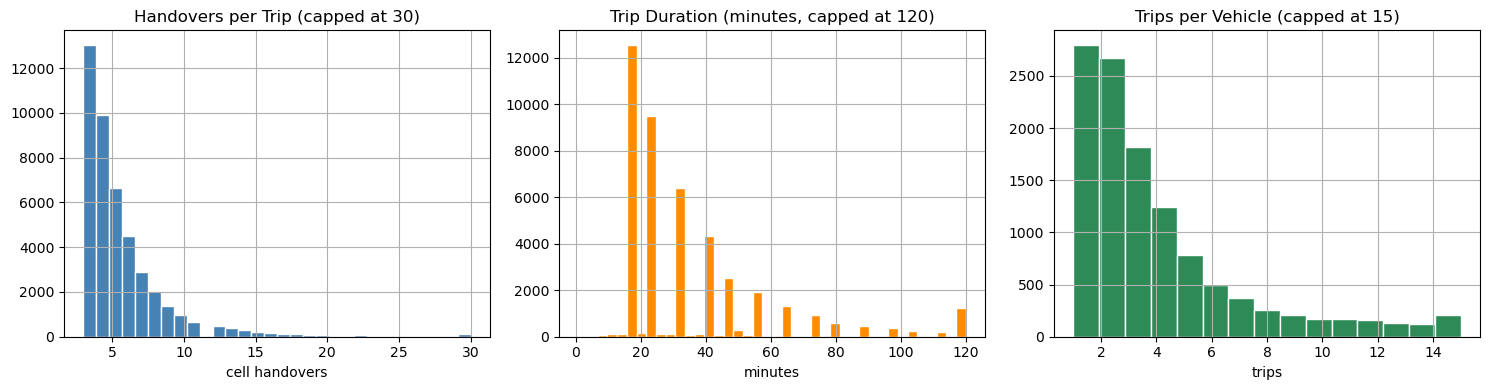

In [13]:
## Step 11 (optional): Visualise

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

trips['n_handovers'].clip(upper=30).hist(
    bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Handovers per Trip (capped at 30)')
axes[0].set_xlabel('cell handovers')

trips['duration_minutes'].clip(upper=120).hist(
    bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Trip Duration (minutes, capped at 120)')
axes[1].set_xlabel('minutes')

trips.groupby('vehicle_id')['trip_id'].count().clip(upper=15).hist(
    bins=15, ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Trips per Vehicle (capped at 15)')
axes[2].set_xlabel('trips')

plt.tight_layout()
plt.show()